In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/competitions/rogii-wellbore-geology-prediction/sample_submission.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/AI_wellbore_geology_prediction_task_en.pptx
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/000d7d20__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00bbac68__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/test/00e12e8b__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/75d20a82__typewell.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/b0f53bf4__horizontal_well.csv
/kaggle/input/competitions/rogii-wellbore-geology-prediction/train/e47

In [2]:
from pathlib import Path
from collections import defaultdict
import os
import gc
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import GroupKFold
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 200)

RANDOM_STATE = 42
FAST_DEBUG = False

N_FOLDS = 3 if FAST_DEBUG else 5
MAX_TRAIN_WELLS = 60 if FAST_DEBUG else None

XGB_PARAMS = {
    "n_estimators": 80 if FAST_DEBUG else 450,
    "learning_rate": 0.06 if FAST_DEBUG else 0.035,
    "max_depth": 5,
    "min_child_weight": 20,
    "subsample": 0.85,
    "colsample_bytree": 0.85,
    "reg_lambda": 4.0,
    "reg_alpha": 0.05,
    "objective": "reg:squarederror",
    "eval_metric": "rmse",
    "tree_method": "hist",
    "max_bin": 256,
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
    "device": "cuda",
}

print("FAST_DEBUG:", FAST_DEBUG)
print("N_FOLDS:", N_FOLDS)
print("XGB_PARAMS:", XGB_PARAMS)


FAST_DEBUG: False
N_FOLDS: 5
XGB_PARAMS: {'n_estimators': 450, 'learning_rate': 0.035, 'max_depth': 5, 'min_child_weight': 20, 'subsample': 0.85, 'colsample_bytree': 0.85, 'reg_lambda': 4.0, 'reg_alpha': 0.05, 'objective': 'reg:squarederror', 'eval_metric': 'rmse', 'tree_method': 'hist', 'max_bin': 256, 'random_state': 42, 'n_jobs': -1, 'device': 'cuda'}


In [3]:
def find_data_root():
    candidates = [
        Path("/kaggle/input/competitions/rogii-wellbore-geology-prediction"),
        Path.cwd(),
    ]
    candidates.extend(Path.cwd().parents)

    for root in candidates:
        if (root / "train").is_dir() and (root / "sample_submission.csv").is_file():
            return root.resolve()
    raise FileNotFoundError("Could not find train/ and sample_submission.csv")

DATA_ROOT = find_data_root()
TRAIN_DIR = DATA_ROOT / "train"
TEST_DIR = DATA_ROOT / "test"
SAMPLE_SUB_PATH = DATA_ROOT / "sample_submission.csv"

print("DATA_ROOT:", DATA_ROOT)
print("TRAIN_DIR:", TRAIN_DIR)
print("TEST_DIR:", TEST_DIR)


DATA_ROOT: /kaggle/input/competitions/rogii-wellbore-geology-prediction
TRAIN_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/train
TEST_DIR: /kaggle/input/competitions/rogii-wellbore-geology-prediction/test


In [4]:
def well_id_from_path(path):
    return Path(path).name.split("__", 1)[0]

train_horizontal_paths = sorted(TRAIN_DIR.glob("*__horizontal_well.csv"))
test_horizontal_paths = sorted(TEST_DIR.glob("*__horizontal_well.csv"))

if MAX_TRAIN_WELLS is not None:
    train_horizontal_paths = train_horizontal_paths[:MAX_TRAIN_WELLS]

print(f"Training horizontal wells used: {len(train_horizontal_paths)}")
print(f"Visible test horizontal wells:  {len(test_horizontal_paths)}")

sample_sub = pd.read_csv(SAMPLE_SUB_PATH)
sample_sub["well_id"] = sample_sub["id"].str.rsplit("_", n=1).str[0]
sample_sub["row_index"] = sample_sub["id"].str.rsplit("_", n=1).str[1].astype(int)

display(sample_sub.head())
display(sample_sub.groupby("well_id").size().rename("rows_to_predict").reset_index().head())

Training horizontal wells used: 773
Visible test horizontal wells:  3


,id,tvt,well_id,row_index
0,000d7d20_1442,0.0,000d7d20,1442
1,000d7d20_1443,0.0,000d7d20,1443
2,000d7d20_1444,0.0,000d7d20,1444
3,000d7d20_1445,0.0,000d7d20,1445
4,000d7d20_1446,0.0,000d7d20,1446


,well_id,rows_to_predict
0,000d7d20,3836
1,00bbac68,6014
2,00e12e8b,4301


In [5]:
def rmse(y_true, y_pred):
    y_true = np.asarray(y_true, dtype=np.float64)
    y_pred = np.asarray(y_pred, dtype=np.float64)
    return float(np.sqrt(np.mean((y_true - y_pred) ** 2)))


def robust_slope(x, y, default=0.0):
    x = np.asarray(x, dtype=np.float64)
    y = np.asarray(y, dtype=np.float64)
    mask = np.isfinite(x) & np.isfinite(y)
    if mask.sum() < 2:
        return default
    x = x[mask]
    y = y[mask]
    if np.nanstd(x) < 1e-6:
        return default
    return float(np.polyfit(x, y, 1)[0])


def safe_interp(x, xp, fp):
    xp = np.asarray(xp, dtype=np.float64)
    fp = np.asarray(fp, dtype=np.float64)
    mask = np.isfinite(xp) & np.isfinite(fp)
    if mask.sum() < 2:
        return np.full_like(np.asarray(x, dtype=np.float64), np.nan, dtype=np.float64)
    order = np.argsort(xp[mask])
    xp = xp[mask][order]
    fp = fp[mask][order]
    return np.interp(np.asarray(x, dtype=np.float64), xp, fp, left=np.nan, right=np.nan)


def make_test_row_map(submission):
    row_map = defaultdict(list)
    for well_id, row_idx in zip(submission["well_id"], submission["row_index"]):
        row_map[well_id].append(int(row_idx))
    return {k: np.array(v, dtype=np.int64) for k, v in row_map.items()}


def load_typewell(well_id, split):
    base = TRAIN_DIR if split == "train" else TEST_DIR
    path = base / f"{well_id}__typewell.csv"
    if path.exists():
        return pd.read_csv(path)
    return pd.DataFrame({"TVT": [], "GR": []})


In [6]:
def build_features_for_well(horizontal_path, split="train", test_row_map=None):
    well_id = well_id_from_path(horizontal_path)
    h = pd.read_csv(horizontal_path)
    tw = load_typewell(well_id, split)

    h["row_index"] = np.arange(len(h), dtype=np.int64)

    # Target/evaluation rows.
    if split == "train":
        row_mask = h["TVT_input"].isna() & h["TVT"].notna()
        selected_idx = h.index[row_mask].to_numpy(dtype=np.int64)
    else:
        if test_row_map is not None and well_id in test_row_map:
            selected_idx = test_row_map[well_id]
        else:
            selected_idx = h.index[h["TVT_input"].isna()].to_numpy(dtype=np.int64)

    if len(selected_idx) == 0:
        return pd.DataFrame()

    known = h[h["TVT_input"].notna()].copy()
    if len(known) == 0:
        # Very defensive fallback. This should not happen in the competition data.
        known = h.head(1).copy()
        known["TVT_input"] = np.nan

    first_missing = h.index[h["TVT_input"].isna()]
    ps_idx = int(first_missing[0]) if len(first_missing) else int(len(h))
    last_known = known.iloc[-1]

    # Slopes from the known segment.
    slope_all = robust_slope(known["MD"], known["TVT_input"])
    recent = known.tail(min(200, len(known)))
    slope_recent = robust_slope(recent["MD"], recent["TVT_input"], default=slope_all)
    slope_z_recent = robust_slope(recent["Z"], recent["TVT_input"])

    # Current rows.
    cur = h.loc[selected_idx, ["MD", "X", "Y", "Z", "GR", "row_index"]].copy()
    cur["well_id"] = well_id
    cur["id"] = cur["well_id"] + "_" + cur["row_index"].astype(str)

    # Per-well known-context constants.
    ps_md = float(last_known.get("MD", np.nan))
    ps_x = float(last_known.get("X", np.nan))
    ps_y = float(last_known.get("Y", np.nan))
    ps_z = float(last_known.get("Z", np.nan))
    ps_gr = float(last_known.get("GR", np.nan))
    last_known_tvt = float(last_known.get("TVT_input", np.nan))

    cur["n_rows"] = len(h)
    cur["prediction_start_index"] = ps_idx
    cur["last_known_tvt"] = last_known_tvt
    cur["known_tvt_min"] = known["TVT_input"].min()
    cur["known_tvt_max"] = known["TVT_input"].max()
    cur["known_tvt_range"] = known["TVT_input"].max() - known["TVT_input"].min()
    cur["known_tvt_mean"] = known["TVT_input"].mean()
    cur["known_tvt_std"] = known["TVT_input"].std()
    cur["known_gr_mean"] = known["GR"].mean() if "GR" in known else np.nan
    cur["known_gr_std"] = known["GR"].std() if "GR" in known else np.nan
    cur["known_gr_min"] = known["GR"].min() if "GR" in known else np.nan
    cur["known_gr_max"] = known["GR"].max() if "GR" in known else np.nan
    cur["last_known_gr"] = ps_gr
    cur["slope_tvt_md_all"] = slope_all
    cur["slope_tvt_md_recent"] = slope_recent
    cur["slope_tvt_z_recent"] = slope_z_recent

    # Relative position after prediction start.
    cur["row_from_ps"] = cur["row_index"] - ps_idx
    cur["row_frac"] = cur["row_index"] / max(len(h) - 1, 1)
    cur["md_from_ps"] = cur["MD"] - ps_md
    cur["x_from_ps"] = cur["X"] - ps_x
    cur["y_from_ps"] = cur["Y"] - ps_y
    cur["z_from_ps"] = cur["Z"] - ps_z
    cur["xy_dist_from_ps"] = np.sqrt(cur["x_from_ps"] ** 2 + cur["y_from_ps"] ** 2)
    cur["xyz_dist_from_ps"] = np.sqrt(cur["xy_dist_from_ps"] ** 2 + cur["z_from_ps"] ** 2)

    # Baselines. XGB2 uses the flat last-known-TVT baseline for residual learning.
    # The slope continuation baselines are retained only as model features.
    cur["baseline_tvt_all_slope"] = last_known_tvt + slope_all * cur["md_from_ps"]
    cur["baseline_tvt_recent_slope"] = last_known_tvt + slope_recent * cur["md_from_ps"]
    cur["baseline_tvt"] = last_known_tvt

    # Horizontal GR features. Interpolate missing GR for rolling/context features but keep a missing flag.
    cur["gr_missing"] = cur["GR"].isna().astype(np.int8)
    gr_filled = h["GR"].astype(float).interpolate(limit_direction="both")
    for window in [11, 51, 151]:
        roll = gr_filled.rolling(window=window, center=True, min_periods=max(2, window // 5))
        cur[f"gr_roll_mean_{window}"] = roll.mean().iloc[selected_idx].to_numpy()
        cur[f"gr_roll_std_{window}"] = roll.std().iloc[selected_idx].to_numpy()
    cur["gr_diff_1"] = gr_filled.diff(1).iloc[selected_idx].to_numpy()
    cur["gr_diff_10"] = gr_filled.diff(10).iloc[selected_idx].to_numpy()
    cur["gr_minus_last_known"] = cur["GR"] - ps_gr

    # Typewell features.
    if {"TVT", "GR"}.issubset(tw.columns) and len(tw) > 1:
        tw_tvt = tw["TVT"].astype(float)
        tw_gr = tw["GR"].astype(float)
        cur["typewell_tvt_min"] = tw_tvt.min()
        cur["typewell_tvt_max"] = tw_tvt.max()
        cur["typewell_tvt_range"] = tw_tvt.max() - tw_tvt.min()
        cur["typewell_gr_mean"] = tw_gr.mean()
        cur["typewell_gr_std"] = tw_gr.std()
        cur["typewell_gr_min"] = tw_gr.min()
        cur["typewell_gr_max"] = tw_gr.max()
        cur["tw_gr_at_last_known_tvt"] = safe_interp(np.array([last_known_tvt]), tw_tvt, tw_gr)[0]
        cur["tw_gr_at_baseline_tvt"] = safe_interp(cur["baseline_tvt"].to_numpy(), tw_tvt, tw_gr)
        cur["tw_gr_at_baseline_all_slope"] = safe_interp(cur["baseline_tvt_all_slope"].to_numpy(), tw_tvt, tw_gr)
        cur["gr_minus_tw_baseline"] = cur["GR"] - cur["tw_gr_at_baseline_tvt"]
        cur["gr_minus_tw_last_known"] = cur["GR"] - cur["tw_gr_at_last_known_tvt"]
    else:
        for col in [
            "typewell_tvt_min", "typewell_tvt_max", "typewell_tvt_range",
            "typewell_gr_mean", "typewell_gr_std", "typewell_gr_min", "typewell_gr_max",
            "tw_gr_at_last_known_tvt", "tw_gr_at_baseline_tvt", "tw_gr_at_baseline_all_slope",
            "gr_minus_tw_baseline", "gr_minus_tw_last_known",
        ]:
            cur[col] = np.nan

    if split == "train":
        cur["target_tvt"] = h.loc[selected_idx, "TVT"].to_numpy()
        cur["target_residual"] = cur["target_tvt"] - cur["baseline_tvt"]

    # Downcast numeric columns to reduce memory.
    for col in cur.columns:
        if col not in ["well_id", "id"]:
            cur[col] = pd.to_numeric(cur[col], downcast="float")

    return cur.reset_index(drop=True)


In [7]:
train_parts = []
for i, path in enumerate(train_horizontal_paths, start=1):
    train_parts.append(build_features_for_well(path, split="train"))
    if i % 100 == 0:
        print(f"Processed {i}/{len(train_horizontal_paths)} train wells")

train_df = pd.concat(train_parts, ignore_index=True)
del train_parts
gc.collect()

print("train_df shape:", train_df.shape)
display(train_df.head())
print("Target rows:", len(train_df))
print("Unique wells:", train_df["well_id"].nunique())


Processed 100/773 train wells
Processed 200/773 train wells
Processed 300/773 train wells
Processed 400/773 train wells
Processed 500/773 train wells
Processed 600/773 train wells
Processed 700/773 train wells
train_df shape: (3783989, 59)


,MD,X,Y,Z,GR,row_index,well_id,id,n_rows,prediction_start_index,last_known_tvt,known_tvt_min,known_tvt_max,known_tvt_range,known_tvt_mean,known_tvt_std,known_gr_mean,known_gr_std,known_gr_min,known_gr_max,last_known_gr,slope_tvt_md_all,slope_tvt_md_recent,slope_tvt_z_recent,row_from_ps,row_frac,md_from_ps,x_from_ps,y_from_ps,z_from_ps,xy_dist_from_ps,xyz_dist_from_ps,baseline_tvt_all_slope,baseline_tvt_recent_slope,baseline_tvt,gr_missing,gr_roll_mean_11,gr_roll_std_11,gr_roll_mean_51,gr_roll_std_51,gr_roll_mean_151,gr_roll_std_151,gr_diff_1,gr_diff_10,gr_minus_last_known,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,typewell_gr_min,typewell_gr_max,tw_gr_at_last_known_tvt,tw_gr_at_baseline_tvt,tw_gr_at_baseline_all_slope,gr_minus_tw_baseline,gr_minus_tw_last_known,target_tvt,target_residual
0,12909.0,2983537.06,1070212.72,-9735.070312,NaN,1442.0,000d7d20,000d7d20_1442,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,0.0,0.273261,1.0,-0.03,1.00,0.01,1.000450,1.000500,11747.672852,11747.370117,11747.370117,1,105.311470,0.890245,103.299164,4.825131,98.586723,14.259318,-0.205555,1.473982,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,95.444763,NaN,NaN,11747.379883,0.01
1,12910.0,2983537.03,1070213.72,-9735.059570,NaN,1443.0,000d7d20,000d7d20_1443,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,1.0,0.273451,2.0,-0.06,2.00,0.02,2.000900,2.001000,11747.975586,11747.370117,11747.370117,1,105.036865,0.962581,102.871223,4.878050,98.374031,14.315206,-0.205555,0.591598,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,97.856438,NaN,NaN,11747.389648,0.02
2,12911.0,2983537.00,1070214.72,-9735.049805,NaN,1444.0,000d7d20,000d7d20_1444,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,2.0,0.273640,3.0,-0.09,3.00,0.03,3.001350,3.001500,11748.278320,11747.371094,11747.370117,1,104.757362,1.017637,102.427391,4.973273,98.155296,14.380600,-0.205555,-0.290786,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.770462,NaN,NaN,11747.400391,0.03
3,12912.0,2983536.97,1070215.71,-9735.040039,104.818207,1445.0,000d7d20,000d7d20_1445,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,3.0,0.273830,4.0,-0.12,3.99,0.04,3.991804,3.992004,11748.581055,11747.371094,11747.370117,0,104.472954,1.056209,101.967651,5.109817,97.930534,14.455724,-0.205555,-1.173170,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.563736,11.505805,11.505805,11747.400391,0.03
4,12913.0,2983536.94,1070216.71,-9735.030273,103.960892,1446.0,000d7d20,000d7d20_1446,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,4.0,0.274019,5.0,-0.15,4.99,0.05,4.992254,4.992505,11748.882812,11747.371094,11747.370117,0,104.137505,1.157626,101.492012,5.285673,97.699738,14.540770,-0.857316,-2.707315,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,96.880966,10.648488,10.648488,11747.410156,0.04


Target rows: 3783989
Unique wells: 773


In [8]:
exclude_cols = {"well_id", "id", "target_tvt", "target_residual"}
feature_cols = [c for c in train_df.columns if c not in exclude_cols]

X = train_df[feature_cols].astype(np.float32)
y_resid = train_df["target_residual"].astype(np.float32)
y_true = train_df["target_tvt"].astype(np.float32)
baseline = train_df["baseline_tvt"].astype(np.float32)
groups = train_df["well_id"].values

print(f"Number of features: {len(feature_cols)}")
print(feature_cols)


Number of features: 55
['MD', 'X', 'Y', 'Z', 'GR', 'row_index', 'n_rows', 'prediction_start_index', 'last_known_tvt', 'known_tvt_min', 'known_tvt_max', 'known_tvt_range', 'known_tvt_mean', 'known_tvt_std', 'known_gr_mean', 'known_gr_std', 'known_gr_min', 'known_gr_max', 'last_known_gr', 'slope_tvt_md_all', 'slope_tvt_md_recent', 'slope_tvt_z_recent', 'row_from_ps', 'row_frac', 'md_from_ps', 'x_from_ps', 'y_from_ps', 'z_from_ps', 'xy_dist_from_ps', 'xyz_dist_from_ps', 'baseline_tvt_all_slope', 'baseline_tvt_recent_slope', 'baseline_tvt', 'gr_missing', 'gr_roll_mean_11', 'gr_roll_std_11', 'gr_roll_mean_51', 'gr_roll_std_51', 'gr_roll_mean_151', 'gr_roll_std_151', 'gr_diff_1', 'gr_diff_10', 'gr_minus_last_known', 'typewell_tvt_min', 'typewell_tvt_max', 'typewell_tvt_range', 'typewell_gr_mean', 'typewell_gr_std', 'typewell_gr_min', 'typewell_gr_max', 'tw_gr_at_last_known_tvt', 'tw_gr_at_baseline_tvt', 'tw_gr_at_baseline_all_slope', 'gr_minus_tw_baseline', 'gr_minus_tw_last_known']


In [9]:
gkf = GroupKFold(n_splits=N_FOLDS)
oof = np.zeros(len(train_df), dtype=np.float32)
fold_rows = []
models = []

for fold, (trn_idx, val_idx) in enumerate(gkf.split(X, y_resid, groups), start=1):
    print(f"\n===== Fold {fold}/{N_FOLDS} =====")
    print(f"Train rows: {len(trn_idx):,} | Valid rows: {len(val_idx):,}")
    print(f"Train wells: {len(np.unique(groups[trn_idx])):,} | Valid wells: {len(np.unique(groups[val_idx])):,}")

    model = XGBRegressor(**XGB_PARAMS)
    model.fit(
        X.iloc[trn_idx],
        y_resid.iloc[trn_idx],
        eval_set=[(X.iloc[val_idx], y_resid.iloc[val_idx])],
        verbose=100,
    )

    val_resid_pred = model.predict(X.iloc[val_idx]).astype(np.float32)
    val_pred = baseline.iloc[val_idx].to_numpy() + val_resid_pred
    oof[val_idx] = val_pred

    fold_rmse = rmse(y_true.iloc[val_idx], val_pred)
    baseline_rmse = rmse(y_true.iloc[val_idx], baseline.iloc[val_idx])

    fold_rows.append({
        "fold": fold,
        "valid_rows": len(val_idx),
        "valid_wells": len(np.unique(groups[val_idx])),
        "baseline_rmse": baseline_rmse,
        "xgb_rmse": fold_rmse,
        "improvement": baseline_rmse - fold_rmse,
    })
    models.append(model)

    print(f"Fold {fold} baseline RMSE: {baseline_rmse:.5f}")
    print(f"Fold {fold} XGB RMSE:      {fold_rmse:.5f}")

cv = pd.DataFrame(fold_rows)
display(cv)
print(f"OOF baseline RMSE: {rmse(y_true, baseline):.5f}")
print(f"OOF XGB RMSE:      {rmse(y_true, oof):.5f}")
print(f"Mean fold RMSE:    {cv['xgb_rmse'].mean():.5f} +/- {cv['xgb_rmse'].std():.5f}")


===== Fold 1/5 =====
Train rows: 3,026,251 | Valid rows: 757,738
Train wells: 618 | Valid wells: 155
[0]	validation_0-rmse:15.19829
[100]	validation_0-rmse:14.56237
[200]	validation_0-rmse:14.54354
[300]	validation_0-rmse:14.45867
[400]	validation_0-rmse:14.48003
[449]	validation_0-rmse:14.46645
Fold 1 baseline RMSE: 15.29015
Fold 1 XGB RMSE:      14.46646

===== Fold 2/5 =====
Train rows: 3,027,339 | Valid rows: 756,650
Train wells: 618 | Valid wells: 155
[0]	validation_0-rmse:15.70818
[100]	validation_0-rmse:14.90178
[200]	validation_0-rmse:14.78906
[300]	validation_0-rmse:14.68884
[400]	validation_0-rmse:14.60181
[449]	validation_0-rmse:14.59461
Fold 2 baseline RMSE: 15.91725
Fold 2 XGB RMSE:      14.59459

===== Fold 3/5 =====
Train rows: 3,027,734 | Valid rows: 756,255
Train wells: 619 | Valid wells: 154
[0]	validation_0-rmse:14.63879
[100]	validation_0-rmse:14.20195
[200]	validation_0-rmse:13.91389
[300]	validation_0-rmse:13.68613
[400]	validation_0-rmse:13.59420
[449]	validatio

,fold,valid_rows,valid_wells,baseline_rmse,xgb_rmse,improvement
0,1,757738,155,15.290149,14.466462,0.823687
1,2,756650,155,15.917252,14.594588,1.322664
2,3,756255,154,14.678227,13.527172,1.151056
3,4,757101,155,16.046960,15.209089,0.837871
4,5,756245,154,17.479987,16.666305,0.813682


OOF baseline RMSE: 15.90987
OOF XGB RMSE:      14.92866
Mean fold RMSE:    14.89272 +/- 1.15985


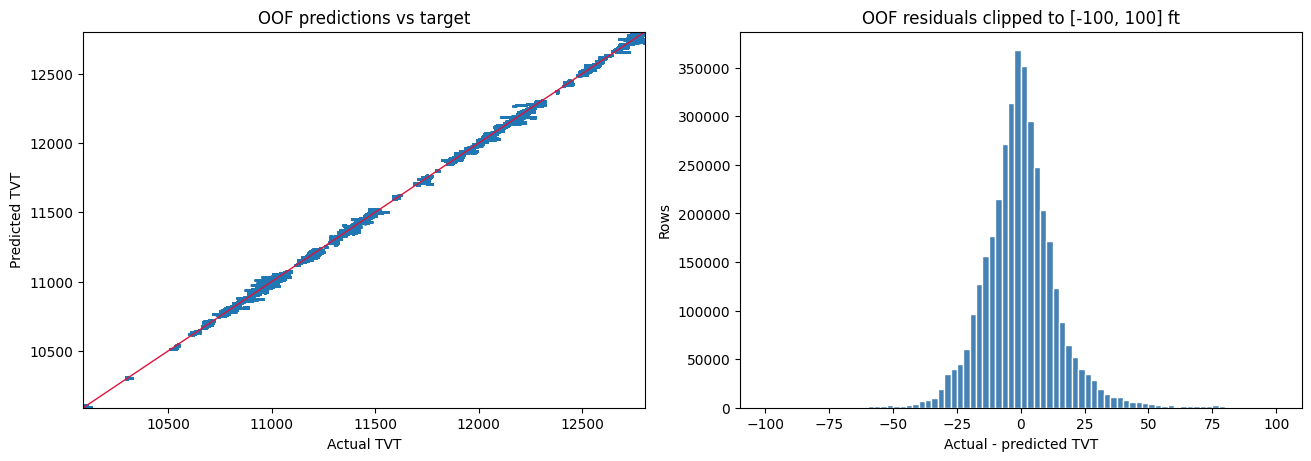

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), constrained_layout=True)

axes[0].scatter(y_true, oof, s=1, alpha=0.08)
lo = float(np.nanpercentile(y_true, 1))
hi = float(np.nanpercentile(y_true, 99))
axes[0].plot([lo, hi], [lo, hi], color="crimson", lw=1)
axes[0].set_xlim(lo, hi)
axes[0].set_ylim(lo, hi)
axes[0].set_title("OOF predictions vs target")
axes[0].set_xlabel("Actual TVT")
axes[0].set_ylabel("Predicted TVT")

resid = y_true.to_numpy() - oof
axes[1].hist(np.clip(resid, -100, 100), bins=80, color="steelblue", edgecolor="white")
axes[1].set_title("OOF residuals clipped to [-100, 100] ft")
axes[1].set_xlabel("Actual - predicted TVT")
axes[1].set_ylabel("Rows")
plt.show()

,feature,fold_1,fold_2,fold_3,fold_4,fold_5,mean_importance
44,typewell_tvt_max,0.063361,0.083022,0.103110,0.112143,0.044865,0.081300
20,slope_tvt_md_recent,0.061785,0.045265,0.062867,0.044943,0.048475,0.052667
11,known_tvt_range,0.062946,0.035104,0.045920,0.055442,0.020990,0.044081
13,known_tvt_std,0.025287,0.051568,0.032047,0.038674,0.037756,0.037067
45,typewell_tvt_range,0.034157,0.041245,0.030043,0.029889,0.049105,0.036888
43,typewell_tvt_min,0.025252,0.031911,0.025560,0.023645,0.072069,0.035687
10,known_tvt_max,0.034411,0.047271,0.035762,0.032406,0.025330,0.035036
19,slope_tvt_md_all,0.031741,0.032212,0.037708,0.030846,0.041207,0.034743
32,baseline_tvt,0.029017,0.019731,0.040385,0.027586,0.049870,0.033318
21,slope_tvt_z_recent,0.032748,0.029908,0.036193,0.021971,0.037378,0.031639


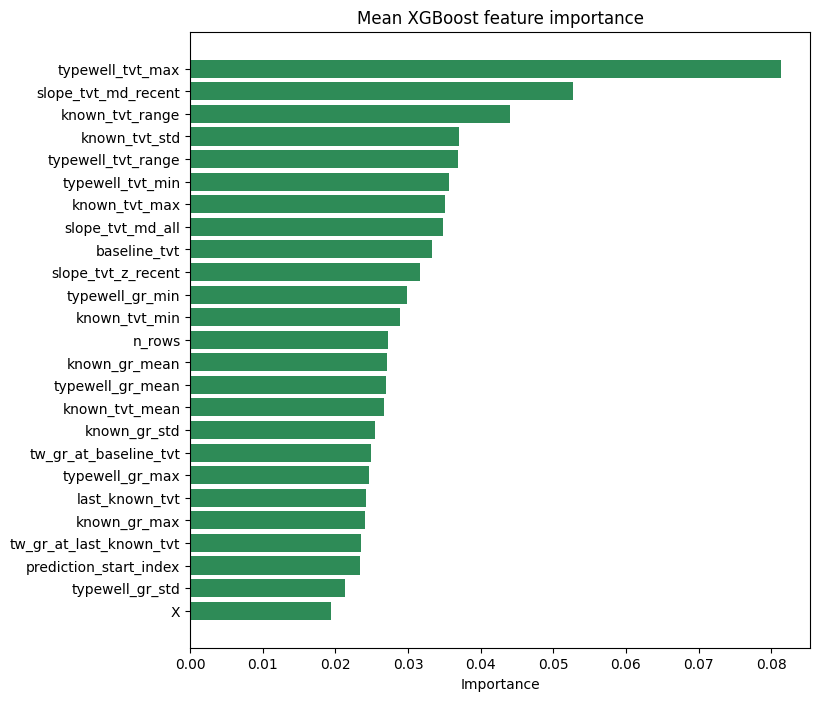

In [11]:
# Average feature importance over folds.
importance = pd.DataFrame({"feature": feature_cols})
for fold, model in enumerate(models, start=1):
    importance[f"fold_{fold}"] = model.feature_importances_
importance["mean_importance"] = importance[[c for c in importance.columns if c.startswith("fold_")]].mean(axis=1)
importance = importance.sort_values("mean_importance", ascending=False)

display(importance.head(25))

fig, ax = plt.subplots(figsize=(8, 8))
top = importance.head(25).sort_values("mean_importance")
ax.barh(top["feature"], top["mean_importance"], color="seagreen")
ax.set_title("Mean XGBoost feature importance")
ax.set_xlabel("Importance")
plt.show()

In [12]:
test_parts = []
for i, path in enumerate(test_horizontal_paths, start=1):
    test_parts.append(build_features_for_well(path, split="test", test_row_map=None))
    if i % 50 == 0:
        print(f"Processed {i}/{len(test_horizontal_paths)} test wells")

test_df = pd.concat(test_parts, ignore_index=True)
del test_parts
gc.collect()

print("test_df shape:", test_df.shape)
display(test_df.head())

test_df shape: (14151, 57)


,MD,X,Y,Z,GR,row_index,well_id,id,n_rows,prediction_start_index,last_known_tvt,known_tvt_min,known_tvt_max,known_tvt_range,known_tvt_mean,known_tvt_std,known_gr_mean,known_gr_std,known_gr_min,known_gr_max,last_known_gr,slope_tvt_md_all,slope_tvt_md_recent,slope_tvt_z_recent,row_from_ps,row_frac,md_from_ps,x_from_ps,y_from_ps,z_from_ps,xy_dist_from_ps,xyz_dist_from_ps,baseline_tvt_all_slope,baseline_tvt_recent_slope,baseline_tvt,gr_missing,gr_roll_mean_11,gr_roll_std_11,gr_roll_mean_51,gr_roll_std_51,gr_roll_mean_151,gr_roll_std_151,gr_diff_1,gr_diff_10,gr_minus_last_known,typewell_tvt_min,typewell_tvt_max,typewell_tvt_range,typewell_gr_mean,typewell_gr_std,typewell_gr_min,typewell_gr_max,tw_gr_at_last_known_tvt,tw_gr_at_baseline_tvt,tw_gr_at_baseline_all_slope,gr_minus_tw_baseline,gr_minus_tw_last_known
0,12909.0,2983537.06,1070212.72,-9735.070312,NaN,1442.0,000d7d20,000d7d20_1442,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,0.0,0.273261,1.0,-0.03,1.00,0.01,1.000450,1.000500,11747.672852,11747.370117,11747.370117,1,105.311470,0.890245,103.299164,4.825131,98.586723,14.259318,-0.205555,1.473982,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,95.444763,NaN,NaN
1,12910.0,2983537.03,1070213.72,-9735.059570,NaN,1443.0,000d7d20,000d7d20_1443,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,1.0,0.273451,2.0,-0.06,2.00,0.02,2.000900,2.001000,11747.975586,11747.370117,11747.370117,1,105.036865,0.962581,102.871223,4.878050,98.374031,14.315206,-0.205555,0.591598,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,97.856438,NaN,NaN
2,12911.0,2983537.00,1070214.72,-9735.049805,NaN,1444.0,000d7d20,000d7d20_1444,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,2.0,0.273640,3.0,-0.09,3.00,0.03,3.001350,3.001500,11748.278320,11747.371094,11747.370117,1,104.757362,1.017637,102.427391,4.973273,98.155296,14.380600,-0.205555,-0.290786,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.770462,NaN,NaN
3,12912.0,2983536.97,1070215.71,-9735.040039,104.818207,1445.0,000d7d20,000d7d20_1445,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,3.0,0.273830,4.0,-0.12,3.99,0.04,3.991804,3.992004,11748.581055,11747.371094,11747.370117,0,104.472954,1.056209,101.967651,5.109817,97.930534,14.455724,-0.205555,-1.173170,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,98.563736,11.505805,11.505805
4,12913.0,2983536.94,1070216.71,-9735.030273,103.960892,1446.0,000d7d20,000d7d20_1446,5278.0,1442.0,11747.370117,11236.019531,11756.120117,520.099976,11646.417969,148.869553,87.416512,22.017109,31.765827,171.643753,NaN,0.302656,0.000257,-0.048643,4.0,0.274019,5.0,-0.15,4.99,0.05,4.992254,4.992505,11748.882812,11747.371094,11747.370117,0,104.137505,1.157626,101.492012,5.285673,97.699738,14.540770,-0.857316,-2.707315,NaN,11223.950195,11871.450195,647.5,83.257637,26.25132,28.66,158.179993,93.312401,93.312401,96.880966,10.648488,10.648488


In [13]:
X_test = test_df[feature_cols].astype(np.float32)
test_baseline = test_df["baseline_tvt"].to_numpy(dtype=np.float32)

test_resid_pred = np.zeros(len(test_df), dtype=np.float32)
for fold, model in enumerate(models, start=1):
    pred = model.predict(X_test).astype(np.float32)
    test_resid_pred += pred / len(models)
    print(f"Predicted test with fold model {fold}")

test_df["tvt"] = test_baseline + test_resid_pred

display(test_df[["id", "baseline_tvt", "tvt"]].head())
print(test_df["tvt"].describe())

Predicted test with fold model 1
Predicted test with fold model 2
Predicted test with fold model 3
Predicted test with fold model 4
Predicted test with fold model 5


,id,baseline_tvt,tvt
0,000d7d20_1442,11747.370117,11746.426758
1,000d7d20_1443,11747.370117,11746.426758
2,000d7d20_1444,11747.370117,11746.426758
3,000d7d20_1445,11747.370117,11746.426758
4,000d7d20_1446,11747.370117,11746.426758


count    14151.000000
mean     11905.000977
std        278.365479
min      11597.907227
25%      11606.715820
50%      11747.130859
75%      12224.339355
max      12227.621094
Name: tvt, dtype: float64


In [14]:
submission = test_df[["id", "tvt"]].copy()
submission["tvt"] = pd.to_numeric(submission["tvt"], errors="coerce")
submission.to_csv("submission.csv", index=False)
print("Saved submission.csv")
print(submission.shape)
display(submission.head())

Saved submission.csv
(14151, 2)


,id,tvt
0,000d7d20_1442,11746.426758
1,000d7d20_1443,11746.426758
2,000d7d20_1444,11746.426758
3,000d7d20_1445,11746.426758
4,000d7d20_1446,11746.426758
